Fashion MNIST – Image Classification using MLP and CNN

In [ ]:
# Importing Libraries

In [ ]:
import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential
from keras.layers import Dense,Flatten
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# Load and explore the data

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [ ]:
#Explore the data
print(f"Training image shape: {x_train.shape}")
print(f"Training label shape: {y_train.shape}")
print(f"Testing image shape: {x_test.shape}")
print(f"Testing label shape: {y_test.shape}")

Training image shape: (60000, 28, 28)
Training label shape: (60000,)
Testing image shape: (10000, 28, 28)
Testing label shape: (10000,)



Display sample data


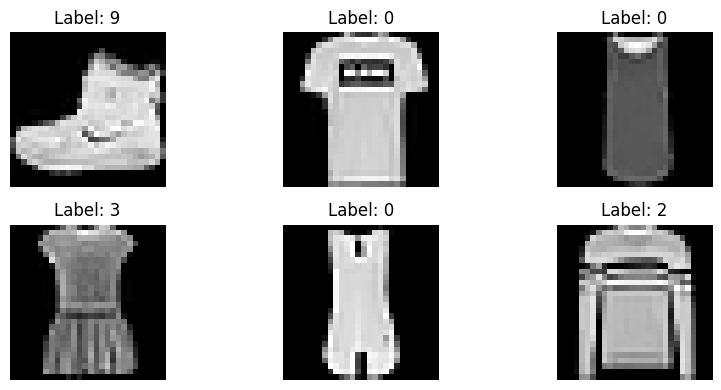

In [ ]:
print("\nDisplay sample data")
plt.figure(figsize=(9,4))
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(x_train[i],cmap='grey')
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
print("Preprocessing data")

x_train_normalized = x_train/255.0
x_test_normalized = x_test/255.0

print(f"Pixel values normalized. Example {x_train_normalized.min(), x_train_normalized.max()} ")

original_train_shape = x_train.shape
original_test_shape = x_test.shape

x_train_flattened = x_train_normalized.reshape(-1, 28*28)
x_test_flattened = x_test_normalized.reshape(-1, 28*28)

print(f"Images flattened from {original_train_shape} to {x_train_flattened.shape}")

Preprocessing data
Pixel values normalized. Example (np.float64(0.0), np.float64(1.0)) 
Images flattened from (60000, 28, 28) to (60000, 784)


In [ ]:
# Converting labels into categorical values (one-hot encoding)
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print(f"Labels converted to one-hot encoding. Example- original: {y_train[0]}, one-hot: {y_train_cat[0]}")
print("Data preprocessing is complete")

Labels converted to one-hot encoding. Example- original: 9, one-hot: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Data preprocessing is complete


In [ ]:
print("Building the MLP model ")

model = keras.Sequential([
    # Input layer
    layers.Input(shape=(784,), name = "input_layer"),
    # Hidden Layer 1
    layers.Dense(128, activation="relu", name = "hidden_layer_1"),
    # Hidden Layer 2
    layers.Dense(64, activation="relu", name = "hidden_layer_2"),
    # Hidden Layer 3
    layers.Dense(32, activation="relu", name = "hidden_layer_3"),
    # Output Layer
    layers.Dense(num_classes, activation="softmax", name="output_layer")

], name = "Fashion_mnist_mlp")

print("Model architecture summary")
model.summary()

print("Model Built successfully")

Building the MLP model 
Model architecture summary


Model: "Fashion_mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Model Built successfully


In [ ]:
print("Compiling and training the model")

# Compiling the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Training the model
history = model.fit(x_train_flattened, y_train_cat, epochs=10, batch_size=32, validation_data=(x_test_flattened,y_test_cat))

Compiling and training the model
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7584 - loss: 0.6883 - val_accuracy: 0.8493 - val_loss: 0.4225
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8594 - loss: 0.3849 - val_accuracy: 0.8644 - val_loss: 0.3834
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8770 - loss: 0.3378 - val_accuracy: 0.8699 - val_loss: 0.3593
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8861 - loss: 0.3104 - val_accuracy: 0.8655 - val_loss: 0.3664
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8900 - loss: 0.2975 - val_accuracy: 0.8729 - val_loss: 0.3580
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8949 - loss: 0.2815 - val_accuracy: 0.8755 - val_loss: 0.3506
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8991 - loss: 0.2678 - val_accuracy: 0.8722 - val_loss: 0.3509
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - a

In [ ]:
print("Evaluating the model on test set")

# Evaluating the trained model on the test set
test_loss, test_acc = model.evaluate(x_test_flattened,y_test_cat, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print("Model evaluation completed")

Evaluating the model on test set
313/313 - 1s - 2ms/step - accuracy: 0.8818 - loss: 0.3411
Test Loss: 0.3411
Test accuracy: 0.8818
Model evaluation completed


Visualizing the training performance


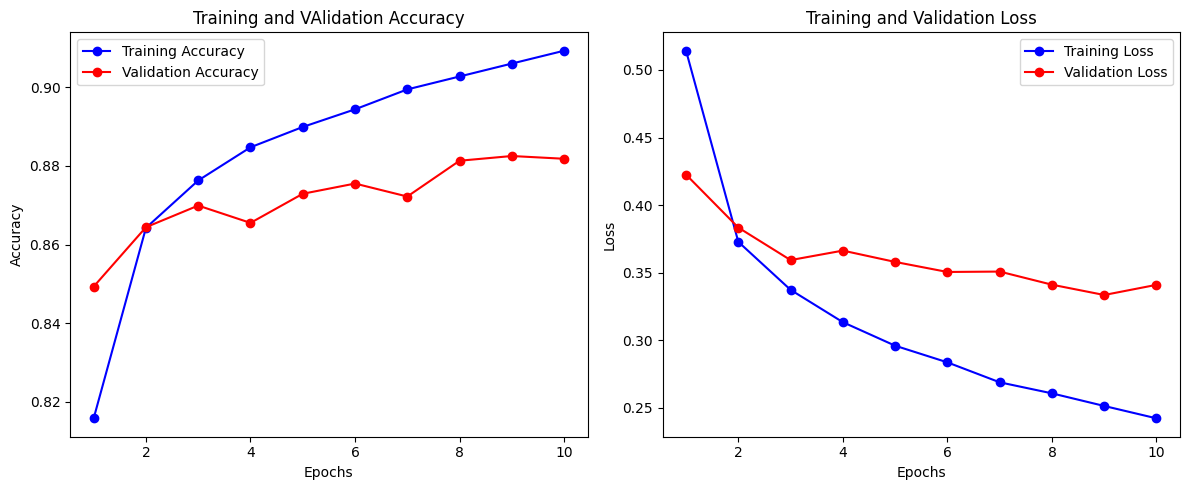

Performance Visualization completed


In [ ]:
print("Visualizing the training performance")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

#plot accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, 'bo-',label= "Training Accuracy", )
plt.plot(epochs_range, val_acc, 'ro-', label = "Validation Accuracy")
plt.title("Training and VAlidation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#plot loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, 'bo-', label = "Training Loss")
plt.plot(epochs_range, val_loss, 'ro-', label = "Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("Performance Visualization completed")

Making predictions and Analyzing results
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Displaying sample test images with preditions


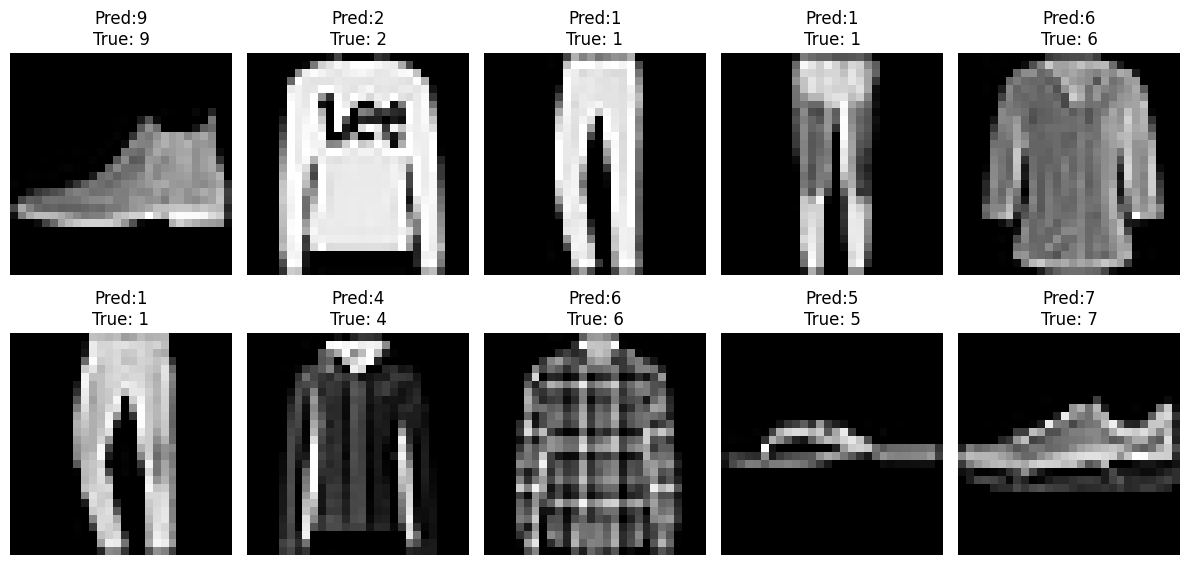


Generating Confusion matrix


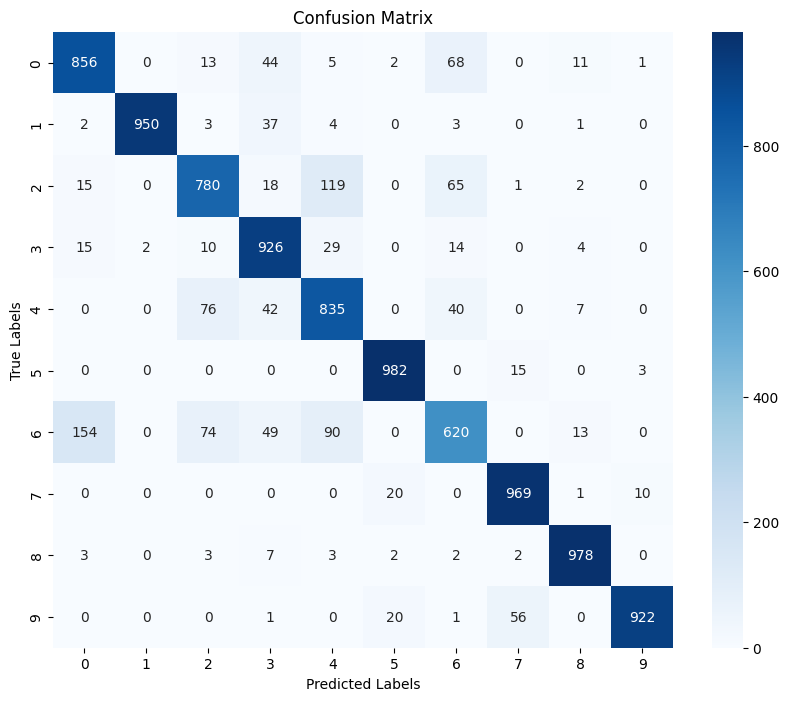


Generating classification report

CLassification Report: 
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      1000
           1       1.00      0.95      0.97      1000
           2       0.81      0.78      0.80      1000
           3       0.82      0.93      0.87      1000
           4       0.77      0.83      0.80      1000
           5       0.96      0.98      0.97      1000
           6       0.76      0.62      0.68      1000
           7       0.93      0.97      0.95      1000
           8       0.96      0.98      0.97      1000
           9       0.99      0.92      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
print("Making predictions and Analyzing results")

prediction_probabilities = model.predict(x_test_flattened)

y_pred = np.argmax(prediction_probabilities, axis = 1)

print("Displaying sample test images with preditions")

plt.figure(figsize=(12,6))
for i in range(10):
  plt.subplot(2,5, i+1)
  plt.imshow(x_test_flattened[i].reshape(28,28), cmap = "gray")
  plt.title(f"Pred:{y_pred[i]}\nTrue: {y_test[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()

print("\nGenerating Confusion matrix")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt = "d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

print("\nGenerating classification report")
report = classification_report(y_test, y_pred, target_names = [str(i) for i in range(10)])
print(f"\nCLassification Report: \n {report}")


# CNN Model

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [ ]:
print(f"Training image shape: {x_train.shape}")
print(f"Training label shape: {y_train.shape}")
print(f"Testing image shape: {x_test.shape}")
print(f"Testing label shape: {y_test.shape}")

Training image shape: (60000, 28, 28)
Training label shape: (60000,)
Testing image shape: (10000, 28, 28)
Testing label shape: (10000,)


In [ ]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /=255
x_test /=255

In [ ]:
x_train = x_train.reshape(x_train.shape[0], 28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)

y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

In [ ]:
from keras.layers import Conv2D,MaxPooling2D

In [ ]:
model1 = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model1.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:

history1 = model1.fit(x_train, y_train,epochs=5,batch_size=32,validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7868 - loss: 0.5799 - val_accuracy: 0.8859 - val_loss: 0.3066
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9015 - loss: 0.2699 - val_accuracy: 0.9058 - val_loss: 0.2575
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9189 - loss: 0.2135 - val_accuracy: 0.9130 - val_loss: 0.2460
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9327 - loss: 0.1802 - val_accuracy: 0.9121 - val_loss: 0.2518
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9430 - loss: 0.1556 - val_accuracy: 0.9202 - val_loss: 0.2447


Displaying random test images with predictions
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


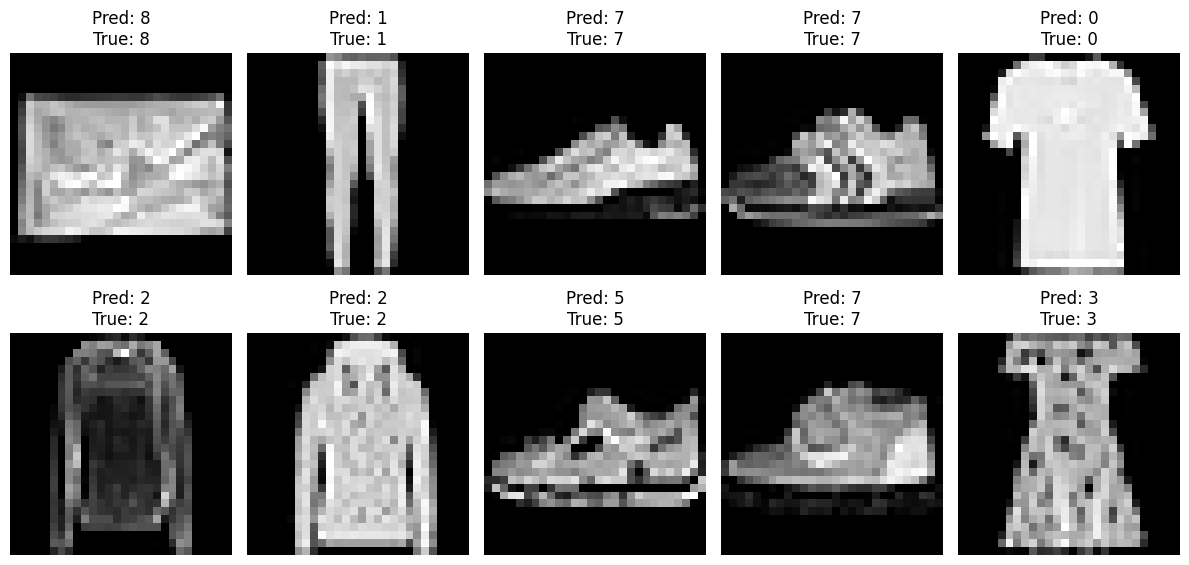

In [ ]:
print("Displaying random test images with predictions")

indices = random.sample(range(len(x_test)), 10)

prediction_probabilities = model1.predict(x_test)
y_pred = np.argmax(prediction_probabilities, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(12, 6))
for idx, i in enumerate(indices):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Prediction Analysis Completed